# **Librerias y Dependencias**

In [213]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd

# **Datos**

In [214]:
angulos = np.array([np.deg2rad(n) for n in range(0,315,45)])

## _Disco_

In [215]:
disco = {
    "Fuerza (N)": np.array([0,0.15,0.2,0.3,0.45,0.7,0.8]),
    "Periodo (s)": 1.8
}

r_disco = 0.15 # m
m_disco = 0.5 # kg

## _Cilindro_

In [216]:
cilindro = {
    "Fuerza (N)": np.array([0,0.2,0.45,0.8,1,1.35,1.58]),
    "Periodo (s)": 1.59
}

r_cilindro = 0.05 # m
m_cilindro = 0.38 # kg

# **Parte 1**

## _Disco_

In [217]:
y_vals = np.array([F*r_disco for F in disco['Fuerza (N)']]).flatten()

m_regress,c_regress,r_sq,p_val,error_D_disco = linregress(angulos,y_vals)

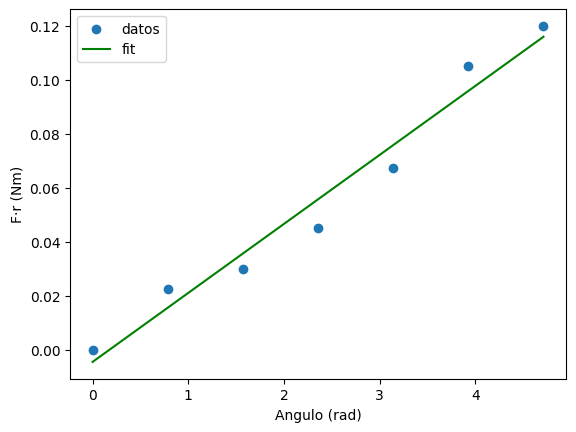

In [218]:
plt.scatter(angulos,y_vals, label="datos")
plt.plot(angulos, m_regress*angulos + c_regress, label="fit", color="g")
plt.xlabel("Angulo (rad)")
plt.ylabel("F·r (Nm)")
plt.legend()
plt.show()

In [219]:
D_disco = m_regress
print(f"D = {D_disco:e}")

D = 2.557847e-02


## _Cilindro_

In [220]:
y_vals = np.array([F*r_cilindro for F in cilindro['Fuerza (N)']]).flatten()

m_regress,c_regress,r_sq,p_val,error_D_cilindro = linregress(angulos,y_vals)

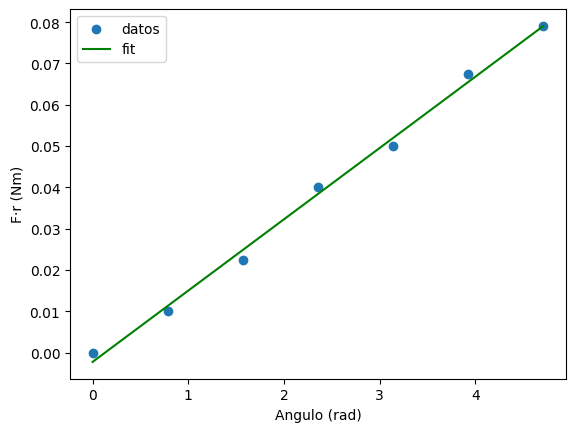

In [221]:
plt.scatter(angulos,y_vals, label="datos")
plt.plot(angulos, m_regress*angulos + c_regress, label="fit", color="g")
plt.xlabel("Angulo (rad)")
plt.ylabel("F·r (Nm)")
plt.legend()
plt.show()

In [222]:
D_cilindro = m_regress
print(f"D = {D_cilindro:e}")

D = 1.725694e-02


# **Parte 2**

In [223]:
I = lambda D,T: (D * (T)**2)/(4 * (np.pi)**2)

## _Disco_

In [224]:
T = disco["Periodo (s)"]
I_disco = I(D_disco,T)
print(f"I = {I_disco:e} kgm^2")

I = 2.099229e-03 kgm^2


## _Cilindro_

In [225]:
T = cilindro["Periodo (s)"]
I_cilindro = I(D_cilindro,T)
print(f"I = {I_cilindro:e} kgm^2")

I = 1.105092e-03 kgm^2


# **Parte 3**

In [226]:
I_teorico = lambda m,r: 0.5 * m * r**2

## _Disco_

In [227]:
I_disco_teorico = I_teorico(m_disco,r_disco)

err_abs = np.abs(I_disco_teorico - I_disco)
err_rel = (err_abs/ I_disco_teorico)*100

print(f"I = {I_disco_teorico:e} kgm^2")
print (f"Error Absoluto: {err_abs:.5f} kgm^2")
print (f"Error Relativo: {err_rel:.3f}%")


I = 5.625000e-03 kgm^2
Error Absoluto: 0.00353 kgm^2
Error Relativo: 62.680%


## _Cilindro_

In [228]:
I_cilindro_teorico = I_teorico(m_cilindro,r_cilindro)

err_abs = np.abs(I_cilindro_teorico - I_cilindro)
err_rel = (err_abs/ I_cilindro_teorico)*100

print(f"I = {I_cilindro_teorico:e} kgm^2")
print (f"Error Absoluto: {err_abs:.5f} kgm^2")
print (f"Error Relativo: {err_rel:.3f}%")


I = 4.750000e-04 kgm^2
Error Absoluto: 0.00063 kgm^2
Error Relativo: 132.651%


# **Parte 4**

In [229]:
err_F = 0.02 # N
err_ang = np.deg2rad(1) # rad
err_T = 0.0005 #s

In [230]:
error_I = lambda D, T, err_D, err_T: np.sqrt(((T**2)/(4*np.pi**2) * err_D)**2 +((2*D*T)/(4*np.pi**2) * err_T)**2)

## _Disco_

In [231]:
T = disco["Periodo (s)"]
err_I_disco = error_I(D_disco,T,error_D_disco, err_T)

In [232]:
print(f"D = {D_disco:e} ± {error_D_disco:.5f} kgm/rad")
print(f"I = {I_disco:e} ± {err_I_disco:.6f} kgm^2")

D = 2.557847e-02 ± 0.00211 kgm/rad
I = 2.099229e-03 ± 0.000173 kgm^2


## _Cilindro_

In [233]:
T = cilindro["Periodo (s)"]
err_I_cilindro = error_I(D_cilindro,T,error_D_cilindro, err_T)

In [234]:
print(f"D = {D_cilindro:e} ± {error_D_cilindro:.6f} kgm/rad")
print(f"I = {I_cilindro:e} ± {err_I_cilindro:.7f} kgm^2")

D = 1.725694e-02 ± 0.000512 kgm/rad
I = 1.105092e-03 ± 0.0000328 kgm^2
